# 🤖 Professional AI Training Pipeline (Jupyter Version)

This notebook implements the full end-to-end Machine Learning pipeline for the Motion Controller.

## Pipeline Stages:
1.  **Data Preparation**: Loading, Cleaning, and Feature Engineering
2.  **Exploratory Data Analysis (EDA)**: Visualizing class balance
3.  **Preprocessing**: Splitting, Scaling, and Encoding
4.  **Model Training**: Multi-Layer Perceptron (Neural Network)
5.  **Evaluation**: Accuracy, Metrics, and Confusion Matrix
6.  **Deployment**: Exporting the model for real-time use

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Setup Path
project_root = os.path.abspath(os.path.join(os.getcwd()))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import src.config as config
from src.data.processing import transform_dataset

print(f'Project Root: {project_root}')

Project Root: d:\ML-AI Motion Controller


## 1. Data Preparation

In [2]:
print('[STEP 1] Data Preparation & Cleaning...')
data_dir = os.path.join(config.DATASET_DIR, 'by_class')
dfs = []

if os.path.exists(data_dir):
    csv_files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
    for file in csv_files:
        file_path = os.path.join(data_dir, file)
        try:
            # Load Raw Data
            df_raw = pd.read_csv(file_path)
            
            # Check for nulls
            if df_raw.isnull().values.any():
                print(f'  ⚠ Warning: Null values found in {file}. Dropping...')
                df_raw = df_raw.dropna()
            
            # TRANSFORM to Pro-Level Features
            df_pro = transform_dataset(df_raw)
            dfs.append(df_pro)
            print(f'  ✓ Loaded {file}: {len(df_pro)} clean samples')
        except Exception as e:
            print(f'  ❌ Error loading {file}: {e}')

if not dfs:
    print('❌ No data found! Please collect data first.')
else:
    df = pd.concat(dfs, ignore_index=True)
    print(f'  📊 Total Dataset: {len(df)} samples')
    print(f'  🧠 Features: {len(df.columns) - 1} input neurons')

[STEP 1] Data Preparation & Cleaning...
  ✓ Loaded block.csv: 500 clean samples
  ✓ Loaded dodge_back.csv: 300 clean samples
  ✓ Loaded dodge_front.csv: 300 clean samples
  ✓ Loaded dodge_left.csv: 300 clean samples
  ✓ Loaded dodge_right.csv: 300 clean samples
  ✓ Loaded final_skill.csv: 300 clean samples
  ✓ Loaded left_punch.csv: 300 clean samples
  ✓ Loaded neutral.csv: 500 clean samples
  ✓ Loaded right_punch.csv: 300 clean samples
  📊 Total Dataset: 3100 samples
  🧠 Features: 72 input neurons


## 2. Exploratory Data Analysis (EDA)

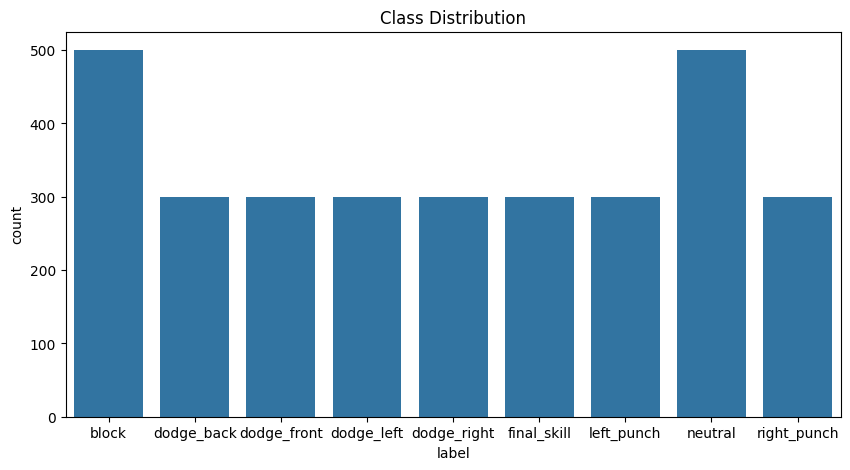

In [3]:
plt.figure(figsize=(10, 5))
sns.countplot(x='label', data=df)
plt.title('Class Distribution')
plt.show()

## 3. Data Splitting & Preprocessing

In [4]:
print('[STEP 2] Data Splitting (Train / Validation / Test)...')
X = df.iloc[:, :-1].values
y = df['label'].values

# Encode and Scale
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# Neural Nets need scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split: Train (70%), Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# Split Temp: Val (15%), Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f'  🔸 Training Set:   {len(X_train)} samples (70%)')
print(f'  🔸 Validation Set: {len(X_val)} samples (15%)')
print(f'  🔸 Test Set:       {len(X_test)} samples (15%)')

[STEP 2] Data Splitting (Train / Validation / Test)...
  🔸 Training Set:   2170 samples (70%)
  🔸 Validation Set: 465 samples (15%)
  🔸 Test Set:       465 samples (15%)


## 4. Model Training (Neural Network)

In [5]:
print('[STEP 3 & 4] Model Architecture & Training Loop...')
model = MLPClassifier(
    hidden_layer_sizes=(128, 64), 
    activation='relu',            
    solver='adam',                
    alpha=0.0001,                 
    batch_size='auto',            
    learning_rate_init=0.001,     
    max_iter=500,                 
    early_stopping=True,          
    validation_fraction=0.1,      
    verbose=True,                 
    random_state=42
)

print(f'  🧠 Architecture: Input(96) -> Dense(128) -> ReLU -> Dense(64) -> ReLU -> Output')
print('  🚀 Starting Backpropagation...')
model.fit(X_train, y_train)

[STEP 3 & 4] Model Architecture & Training Loop...
  🧠 Architecture: Input(96) -> Dense(128) -> ReLU -> Dense(64) -> ReLU -> Output
  🚀 Starting Backpropagation...
Iteration 1, loss = 1.99151561
Validation score: 0.640553
Iteration 2, loss = 1.21800077
Validation score: 0.774194
Iteration 3, loss = 0.80906968
Validation score: 0.870968
Iteration 4, loss = 0.54451896
Validation score: 0.940092
Iteration 5, loss = 0.38704088
Validation score: 0.958525
Iteration 6, loss = 0.29102069
Validation score: 0.958525
Iteration 7, loss = 0.22353920
Validation score: 0.972350
Iteration 8, loss = 0.17916138
Validation score: 0.972350
Iteration 9, loss = 0.14711396
Validation score: 0.976959
Iteration 10, loss = 0.12427330
Validation score: 0.981567
Iteration 11, loss = 0.10553689
Validation score: 0.986175
Iteration 12, loss = 0.09317440
Validation score: 0.981567
Iteration 13, loss = 0.08101905
Validation score: 0.981567
Iteration 14, loss = 0.07310096
Validation score: 0.981567
Iteration 15, loss 

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


## 5. Evaluation

[STEP 5] Evaluation (Test Set)...
  🏆 Test Accuracy: 98.49%

Classification Report:
               precision    recall  f1-score   support

       block       1.00      1.00      1.00        75
  dodge_back       0.96      1.00      0.98        45
 dodge_front       1.00      0.98      0.99        45
  dodge_left       1.00      0.98      0.99        45
 dodge_right       1.00      1.00      1.00        45
 final_skill       1.00      1.00      1.00        45
  left_punch       1.00      0.98      0.99        45
     neutral       0.95      1.00      0.97        75
 right_punch       0.98      0.91      0.94        45

    accuracy                           0.98       465
   macro avg       0.99      0.98      0.98       465
weighted avg       0.99      0.98      0.98       465



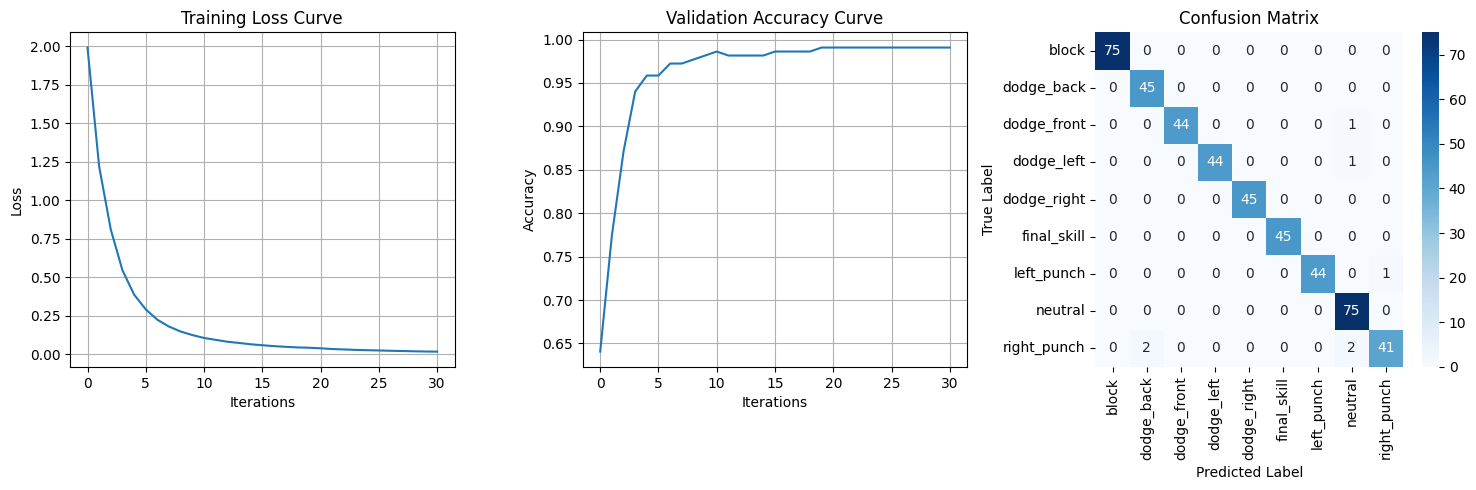

In [6]:
print('[STEP 5] Evaluation (Test Set)...')
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f'  🏆 Test Accuracy: {acc*100:.2f}%')
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=encoder.classes_))

# 1. Plot Loss Curve (Convergence)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(model.loss_curve_)
plt.title('Training Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True)

# 2. Plot Validation Accuracy Curve
plt.subplot(1, 3, 2)
if hasattr(model, 'validation_scores_'):
    plt.plot(model.validation_scores_)
    plt.title('Validation Accuracy Curve')
    plt.xlabel('Iterations')
    plt.ylabel('Accuracy')
    plt.grid(True)

# 3. Confusion Matrix
plt.subplot(1, 3, 3)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=encoder.classes_, yticklabels=encoder.classes_, cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()

## 6. Deployment & Export

In [7]:
print('[STEP 6] Deployment & Export...')
config.ensure_directories()

# Save Model
with open(config.MODEL_FILE, 'wb') as f:
    pickle.dump(model, f)
    
# Save Encoder
with open(config.ENCODER_FILE, 'wb') as f:
    pickle.dump(encoder, f)
    
# Save Scaler
with open(config.SCALER_FILE, 'wb') as f:
    pickle.dump(scaler, f)
    
print(f'  ✅ Model saved:   {config.MODEL_FILE}')
print(f'  ✅ Encoder saved: {config.ENCODER_FILE}')
print(f'  ✅ Scaler saved:  {config.SCALER_FILE}')
print('\n🎉 TRAINING COMPLETE! System is ready.')

[STEP 6] Deployment & Export...
✓ Directories ready: d:\ML-AI Motion Controller\dataset, d:\ML-AI Motion Controller\models
  ✅ Model saved:   d:\ML-AI Motion Controller\models\boxing_model.pkl
  ✅ Encoder saved: d:\ML-AI Motion Controller\models\label_encoder.pkl
  ✅ Scaler saved:  d:\ML-AI Motion Controller\models\scaler.pkl

🎉 TRAINING COMPLETE! System is ready.
